# ResNet Classifier - Make, Model, Year
Combining VMMRdb and StanfordCars into a single dataset to train on.

### Hyperparameters

In [1]:
# Num of images per class
MIN_CLASSES = 40
MAX_CLASSES = 100

# batch size
BATCH_SIZE = 256

# Number of iterations over dataset
epochs = 120

## Imports

In [2]:
# PyTorch
import torchvision.transforms as tt
from torch.utils.data import Dataset
from torch.utils.data import ConcatDataset
from torchvision.datasets.folder import default_loader
from torch.utils.data import DataLoader
from torch.utils.data import Subset
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import torch

# Extra
from collections import Counter, defaultdict
import scipy.io as sio
import pathlib
import os
import re
from PIL import Image
from tqdm import tqdm
import kagglehub
import random
import matplotlib.pyplot as plt
import time

## StanfordCars Setup

### Download Dataset
Downloading the stanford cars dataset from Kaggle

In [3]:
path_stanford_cars = kagglehub.dataset_download("eduardo4jesus/stanford-cars-dataset")

print("Path to dataset files:", path_stanford_cars)

Using Colab cache for faster access to the 'stanford-cars-dataset' dataset.
Path to dataset files: /kaggle/input/stanford-cars-dataset


### StanfordCars Dataset Definition
Stanford dataset class that's been modified from the PyTorch implementation

In [4]:
class StanfordCars(Dataset):
    def __init__(self, root, global_class_to_idx, transform=None, max_images_per_class=None, class_normalizer=None):
        self.root = pathlib.Path(root)
        self.class_to_idx = global_class_to_idx
        self.loader = default_loader
        self.transform = transform
        self.class_normalizer = class_normalizer
        self.class_counts = Counter()

        # Paths
        devkit = self.root / "car_devkit/devkit"
        ann_path = devkit / "cars_train_annos.mat"
        img_dir = self.root / "cars_train/cars_train"

        # Loading metadata from matlab files
        annotations = sio.loadmat(ann_path, squeeze_me=True)["annotations"]
        raw_classes = sio.loadmat(devkit / "cars_meta.mat", squeeze_me=True)["class_names"].tolist()

        self.samples = []

        # Building the dataset list, images labeled with their corresponding normalized class labels
        for ann in annotations:
            path = str(img_dir / ann["fname"])
            cls = raw_classes[ann["class"] - 1]

            # Normalized class
            if class_normalizer:
                cls = class_normalizer(cls)

            idx = self.class_to_idx.get(cls, None)
            if idx is None:
              continue

            # Skip images after max number of images per class has been hit
            if max_images_per_class and self.class_counts[cls] >= max_images_per_class:
              continue

            # Grouping image paths with their new class label
            self.samples.append((path, idx))
            self.class_counts[cls] += 1

    def __len__(self):
        return len(self.samples)

    # Given an index returns the corresponding transformed image, along with their class label
    def __getitem__(self, idx):
        path, y = self.samples[idx]
        img = self.loader(path)
        if self.transform:
            img = self.transform(img)
        return img, y

## VMMRdb Setup

### Dataset Download
Downloading the VMMRdb dataset from Kaggle

In [5]:
path_vmmrdb = kagglehub.dataset_download("prabashwara/vmmrdb-dataset")

print("Path to dataset files:", path_vmmrdb)

100%|██████████| 11.5G/11.5G [02:23<00:00, 86.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/prabashwara/vmmrdb-dataset/versions/1


### Custom VMMRDB Dataset Definition
Defining a PyTorch dataset class for easy access to the image data using PyTorch `DataLoaders`.

In [6]:
class VMMRDB_Dataset(Dataset):
    def __init__(self, root_dir, global_class_to_idx, class_normalization, max_images_per_class=None, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.class_to_idx = global_class_to_idx
        self.classes = []
        self.class_counts = Counter()

        # Images to class names
        # Class names are in the folder names
        for class_name in sorted(os.listdir(root_dir)):
          class_path = os.path.join(root_dir, class_name)
          if os.path.isdir(class_path):

            # Normalizing the class names and getting the index for said class
            stripped = class_normalization(class_name)
            idx = self.class_to_idx.get(stripped, None)
            if idx is None:
              continue

            # Labeling all images with their corresponding classes +
            # skipping images after max number of images per class has been hit
            for img_name in os.listdir(class_path):
              if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                if max_images_per_class and self.class_counts[stripped] >= max_images_per_class:
                  continue
                self.image_paths.append(os.path.join(class_path, img_name))
                self.labels.append(idx)
                self.class_counts[stripped] += 1


        self.classes = self.class_to_idx.keys()

    # Overridden length function
    def __len__(self):
        return len(self.image_paths)

    # Given an index, retrieves the transformed
    # image and corresponding class label
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        return image, label

## Dataset Combination

### Normalization Function
This function is used to normalize the class labels in both the VMMRdb dataset and StanfordCars dataset

In [7]:
# All components that show up in class names that aren't part of model or make
EXTRA = {
    'sedan', 'coupe', 'convertible', 'hatchback', 'suv', 'wagon', 'van',
    'minivan', 'pickup', 'truck', 'cab', 'crew', 'extended', 'regular',
    'quad', 'club', 'cargo', 'passenger', 'sut', 'roadster', 'hybrid',
    'conv.', 'drophead', 'supercab', 'classic', 'superleggera',
    'abarth', 'activehybrid', 'series', 'electric',
}

# Normalizes classes in both datasets
def normalize_classes(car_class):
  car_class = re.sub('_', ' ', car_class).lower()
  car_class = re.sub("-", "", car_class)
  car_class_components = car_class.split(" ")

  # Removing all parts of the class not corresponding to model, make and year
  car_class_components = [t for t in car_class_components if t not in EXTRA]

  # Normalizing some more inconsistencies between the two datasets
  car_class_components = ["mercedes benz" if t == "mercedesbenz" else t for t in car_class_components]
  car_class_components = ["rolls royce" if t == "rollsroyce" else t for t in car_class_components]

  return " ".join(car_class_components)

### Combining the two datasets
Using a minimum number of 40 images and a maximum number of 100 per class.

In [8]:
# Building global class_to_idx so we can combine the two datasets properly

def build_global_class_to_idx(stanford_root, vmmrdb_root, normalize_classes, min_classes):
    class_counts = Counter()


    # Stanford Cars
    devkit = pathlib.Path(stanford_root) / "car_devkit/devkit"
    ann_path = devkit / "cars_train_annos.mat"
    annotations = sio.loadmat(ann_path, squeeze_me=True)["annotations"]
    raw_classes = sio.loadmat(devkit / "cars_meta.mat", squeeze_me=True)["class_names"].tolist()

    # Normalizing class names + retrieving image count per class
    for ann in annotations:
        cls = normalize_classes(raw_classes[ann["class"] - 1])
        class_counts[cls] += 1

    # VMMRdb
    for class_name in sorted(os.listdir(vmmrdb_root)):
        class_path = os.path.join(vmmrdb_root, class_name)
        if os.path.isdir(class_path):

            # Normalizing class names + retrieving image count per class
            cls = normalize_classes(class_name)
            for img in os.listdir(class_path):
                if img.lower().endswith((".jpg", ".jpeg", ".png")):
                    class_counts[cls] += 1

    # Removing classes with less than min_classes number of images
    trimmed_classes = {cls for cls, count in class_counts.items() if count >= min_classes}
    class_to_idx = {cls : idx for idx, cls in enumerate(sorted(trimmed_classes))}
    class_counts = {cls : count for cls,count in class_counts.items() if cls in trimmed_classes}

    return class_to_idx, class_counts

# Building the global class to idx and finding the number of images per class + removes classes with less than MIN_CLASSES images
global_class_to_idx, class_counts = build_global_class_to_idx(path_stanford_cars, path_vmmrdb, normalize_classes, MIN_CLASSES)

### Defining Training and Test Transforms

#### Image Normalization Calculation
Run the following cell if MIN_CLASSES or MAX_CLASSES is modified or the dataset is modified to get the new pixel mean and std. Then replace mean and std in the cell following this one with the new mean and std.

In [9]:
transform = tt.Compose([
    tt.Resize((224,224)),
    tt.ToTensor(),
])

# Need both datasets to calculate image pixel mean and standard deviation
stanford_dataset = StanfordCars(
    root=path_stanford_cars,
    global_class_to_idx=global_class_to_idx,
    class_normalizer=normalize_classes,
    max_images_per_class = MAX_CLASSES,
    transform=transform
)
vmmrdb_dataset = VMMRDB_Dataset(
    root_dir=path_vmmrdb,
    global_class_to_idx=global_class_to_idx,
    class_normalization=normalize_classes,
    max_images_per_class = MAX_CLASSES,
    transform=transform
)

# Full dataset + dataloader
full_dataset = ConcatDataset([stanford_dataset, vmmrdb_dataset])
data_loader = DataLoader(full_dataset, BATCH_SIZE, num_workers = 4, pin_memory = True, shuffle=False)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [11]:
# Mean and Standard Deviation Calculation

mean = 0
ex2 = 0
total_pixels = 0

# Easy visualization of progress
visual_loader = tqdm(data_loader)

for images, _ in visual_loader:
    B, C, H, W = images.shape

    images = images.view(B, C, -1) #(B,C,H,W) -> (B, C, (H x W))

    # Summing across dimensions + (W x H)
    mean += images.sum(dim=(0, 2))

    # Effecitvely summing each pixel per RGB channel with itself (X^2)
    ex2 += (images ** 2).sum(dim=(0, 2))

    # Need to keep track of the total number of pixels to calculate
    # the expected values for each channel
    total_pixels += B * H * W

    visual_loader.set_description("mean + std calculation")

# Calculating the expected value
mean /= total_pixels
ex2 /= total_pixels

# Using std = sqrt(E[X^2] - (E[X])^2)
std = torch.sqrt(ex2 - mean ** 2)

print()
print("Mean:", mean)
print("Std:", std)

#### Dataset Transform definitions
Separating the transform definitions for the test and train sets, with the training dataset using data augmentation. \
Image normalization is used to help speed up convergence and stabilize training.

In [49]:
mean = [0.4369, 0.4330, 0.4285]
std = [0.2681, 0.2649, 0.2673]

# Defines image preprocessing for the training and test datasets
train_transform = tt.Compose([
    tt.Resize((224,224)),

    # Random Transformations
    tt.RandomHorizontalFlip(),
    tt.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    tt.RandomRotation(100),

    tt.ToTensor(),
    tt.Normalize(mean, std)
])

# Transforms limited to resizing, converting to a tensor
# and normalization
test_transform = tt.Compose([
    tt.Resize((224,224)),
    tt.ToTensor(),
    tt.Normalize(mean, std)
])

### Defining Datasets For Training and Testing

In [50]:
# Need to create the dataset objects
# twice to properly create the test and training sets with the correct
# transforms tied to them

# Test dataset
stanford_test = StanfordCars(
    root=path_stanford_cars,
    global_class_to_idx=global_class_to_idx,
    class_normalizer=normalize_classes,
    max_images_per_class = MAX_CLASSES,
    transform=test_transform
)
vmmrdb_test = VMMRDB_Dataset(
    root_dir=path_vmmrdb,
    global_class_to_idx=global_class_to_idx,
    class_normalization=normalize_classes,
    max_images_per_class = MAX_CLASSES,
    transform=test_transform
)

# Train dataset
stanford_train = StanfordCars(
    root=path_stanford_cars,
    global_class_to_idx=global_class_to_idx,
    class_normalizer=normalize_classes,
    max_images_per_class = MAX_CLASSES,
    transform=train_transform
)
vmmrdb_train = VMMRDB_Dataset(
    root_dir=path_vmmrdb,
    global_class_to_idx=global_class_to_idx,
    class_normalization=normalize_classes,
    max_images_per_class = MAX_CLASSES,
    transform=train_transform
)

### Splitting the Training and Testing datasets

In [51]:
# Splitting into training and testing
full = ConcatDataset([stanford_train, vmmrdb_train])

# 70 - 10 - 20 split
train_size = int(0.70 * len(full))
val_size = int(0.10 * len(full))
test_size = len(full) - val_size - train_size

# Separating into test + train + val sets
generator = torch.Generator().manual_seed(0)
indices = torch.randperm(len(full), generator=generator)
train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

# Creating the full combined datasets
dataset_train = Subset(ConcatDataset([stanford_train, vmmrdb_train]), train_indices)
dataset_val = Subset(ConcatDataset([stanford_test, vmmrdb_test]), val_indices)
dataset_test = Subset(ConcatDataset([stanford_test, vmmrdb_test]), test_indices)

# Creating the data loaders
train_loader = DataLoader(dataset_train, BATCH_SIZE, num_workers = 4, pin_memory = True, shuffle=True)
val_loader = DataLoader(dataset_val, BATCH_SIZE, num_workers = 4, pin_memory = True, shuffle=False)
test_loader = DataLoader(dataset_test, BATCH_SIZE, num_workers = 4, pin_memory = True, shuffle=False)

### ResNet-50
Using the ResNet-50 Architecture to train a model that predicts model, make and year

In [52]:
class Bottleneck(nn.Module):
  expansion = 4
  def __init__(self, in_channels, out_channels, stride=1):
    super(Bottleneck, self).__init__()

    # 1x1 conv to reduce channels
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
    self.batch_norm1 = nn.BatchNorm2d(out_channels)

    # 3x3 conv to process on reduced channels
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
    self.batch_norm2 = nn.BatchNorm2d(out_channels)

    # 1x1 conv to expand channels
    self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, stride=1, padding=0, bias=False)
    self.batch_norm3 = nn.BatchNorm2d(out_channels * self.expansion)

    # Skip Connection
    self.shortcut = nn.Sequential()

    # Projection shortcut used when dimension doesn't match
    # This fixes any channel (depth) mismatch or a spatial mismatch
    if stride != 1 or in_channels != out_channels * self.expansion:
      self.shortcut = nn.Sequential(
          nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
          nn.BatchNorm2d(out_channels * self.expansion)
      )

  def forward(self, x):

    # Channel reduction
    out = F.relu(self.batch_norm1(self.conv1(x)))
    # Process
    out = F.relu(self.batch_norm2(self.conv2(out)))
    # Channel expansion
    out = self.batch_norm3(self.conv3(out))
    # Residual connection
    out += self.shortcut(x)
    return F.relu(out)

class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1000):
        super(ResNet, self).__init__()

        # First layer works to aggressively downsample the input image
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2,
                               padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # ResNet layers
        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        # Last layers working to predict the classes
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride):
        layers = []

        # First block
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels * block.expansion

        # Remaining blocks
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        # First convolution step using 7x7 kernels
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        # ResNet Layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Fully connected portion
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x



def ResNet50(num_classes):
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes)

## Training Code

In [17]:
# Defines our ResNet model, loss (cross entropy) and optimizer (Adam)
device = "cuda" if torch.cuda.is_available() else "cpu"
loss_criterion = nn.CrossEntropyLoss()
net = ResNet50(num_classes=len(global_class_to_idx)).to(device)
optimizer = optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-4)

# Checkpoint paths + logging file
checkpoint_path = "./checkpoint.pth"
best_checkpoint_path = "./best_checkpoint.pth"
log_file = "logging.txt"

# Train loss, val loss and val accuracy
train_losses = []
val_losses = []
val_accuracies = []
best_val_acc = 0.0
start_epoch = 0

# Used to keep training stable even when using mixed precision training
scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available()) # for gpu useage


# Try to load trained weights + epoch information
# Used to train multiple multiple times + allows training to be stopped
try:
    checkpoint = torch.load(checkpoint_path, map_location=device)
    net.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    val_accuracies = checkpoint.get("val_accuracies", [])
    best_val_acc = checkpoint.get("best_val_acc", 0.0)
    start_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {start_epoch}")
except FileNotFoundError:
    print("No checkpoint found, starting fresh.")

# Training loop
for epoch in range(start_epoch, epochs):
  # Tracking epoch time (used for the logging file)
  # + extra epoch info
  epoch_start_time = time.time()
  running_loss = 0
  num_batches = 0

  # Allows for a visual indicator of epoch progress
  train_loop = tqdm(train_loader, leave=True)
  net.train()


  for X, y in train_loop:
    X = X.to(device, non_blocking =  True)
    y = y.to(device, non_blocking = True)
    optimizer.zero_grad()

    # Allows us to train our model using mixed precision (AMP)
    with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
        output = net(X)
        loss = loss_criterion(output, y)

    # Using our scaler as a step in for backpropogation and our optimizer step
    # it also adjusts loss to keep everything stable
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    # Keeping track of total training loss for the epoch
    running_loss += loss.item()
    num_batches += 1

    train_loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
    train_loop.set_postfix(loss=loss.item())

  # Calculating and keeping track of the average training loss
  train_loss = running_loss / num_batches
  train_losses.append(train_loss)

  # Validation loss and accuracy
  net.eval()
  val_loss = 0
  val_batches = 0
  correct = 0
  total = 0

  with torch.no_grad():
    # Visual indicator again
    val_loop = tqdm(val_loader, leave=True)

    for X, y in val_loop:
      X = X.to(device, non_blocking = True)
      y = y.to(device, non_blocking = True)

      # We're using mixed precision during validation inference too
      with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
        output = net(X)
        loss = loss_criterion(output, y)

      # We keep track of total validation loss, and total number of correct predictions
      val_loss += loss.item()
      val_batches += 1
      prediction = output.argmax(dim=1)
      correct += (prediction == y).sum().item()
      total += y.size(0)

      val_loop.set_description(f"Validation")
      val_loop.set_postfix(loss=loss.item())

  # Calculating the average validation loss and average validation accuracy
  # and keeping track of both
  val_loss /= val_batches
  val_acc = correct / total
  val_losses.append(val_loss)
  val_accuracies.append(val_acc)

  print(f"Epoch {epoch+1} finished. Train Loss: {train_losses[-1]}, Val Loss={val_losses[-1]}, Val Acc={val_accuracies[-1]}")

  # Logging epoch data into a file (used to measure progress when exiting webpage, if using in jupyter)
  epoch_time = time.time() - epoch_start_time
  log_line = (
      f"Epoch {epoch+1} | "
      f"Train Loss: {train_losses[-1]:.4f} | "
      f"Val Loss: {val_losses[-1]:.4f} | "
      f"Val Acc: {val_accuracies[-1]:.4f} | "
      f"Time: {epoch_time:.2f}s\n"
  )
  with open(log_file, "a") as f:
      f.write(log_line)

  # We save the best model
  if val_acc > best_val_acc:
    best_val_acc = val_acc
    checkpoint = {
      "epoch": epoch,
      "model_state": net.state_dict(),
      "optimizer_state": optimizer.state_dict(),
      "train_losses": train_losses,
      "val_losses": val_losses,
      "val_accuracies": val_accuracies,
      "best_val_acc": best_val_acc
    }
    torch.save(checkpoint, best_checkpoint_path)

  # We also save the model every epoch
  checkpoint = {
    "epoch": epoch,
    "model_state": net.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses,
    "val_accuracies": val_accuracies,
    "best_val_acc": best_val_acc
  }
  torch.save(checkpoint, checkpoint_path)


## Model Accuracy on Test Set
We calculate both the Top-1 accuracy, along with the Top-5 accuracy. Given the granular nature of predicting car `year`, along with `make` and `model`, Top-5 accuracy should give a better indicator of our model's performance.

In [53]:
correct = 0
top5_correct = 0
total = 0

checkpoint = torch.load(checkpoint_path, map_location=device)
net = ResNet50(num_classes=len(global_class_to_idx)).to(device)
net.load_state_dict(checkpoint["model_state"])

# Evaluating the accuracy on the test dataset
net.eval()
with torch.no_grad():
    # Progress visualization
    visual_loader = tqdm(test_loader, leave=True)

    for X, y in visual_loader:
        X = X.to(device)
        y = y.to(device)

        outputs = net(X)

        # Top-1 correct predictions
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y).sum().item()

        # Checks top 5 for the correct prediction
        top5 = torch.topk(outputs, 5, dim=1).indices
        top5_correct += (top5 == y.unsqueeze(1)).any(dim=1).sum().item()

        total += y.size(0)

        visual_loader.set_description("Evaluating")
        visual_loader.set_postfix(
            top1=correct / total,
            top5=top5_correct / total
        )

# Both top 1 and top 5 accuracy over the entire dataset
top1_acc = correct / total
top5_acc = top5_correct / total

print()
print(f"Top-1 Accuracy: {top1_acc:.4f}")
print(f"Top-5 Accuracy: {top5_acc:.4f}")

Evaluating: 100%|██████████| 121/121 [02:44<00:00,  1.36s/it, top1=0.672, top5=0.829]


Top-1 Accuracy: 0.6717
Top-5 Accuracy: 0.8287


## Visualizing Loss and Accuracy over epoch
Plotting Training and Validation loss over epoch, along with validation accuracy over epoch.

Best Validation Accuracy: 0.3940


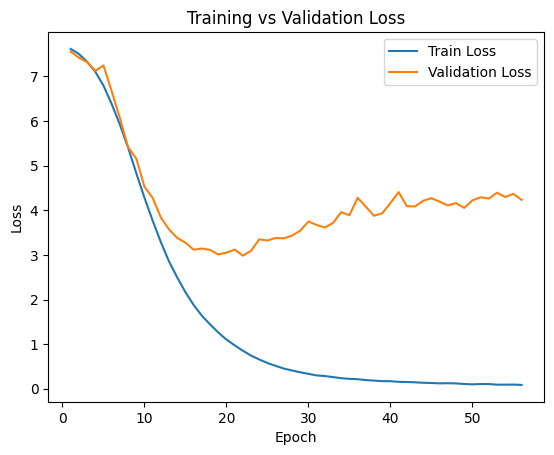

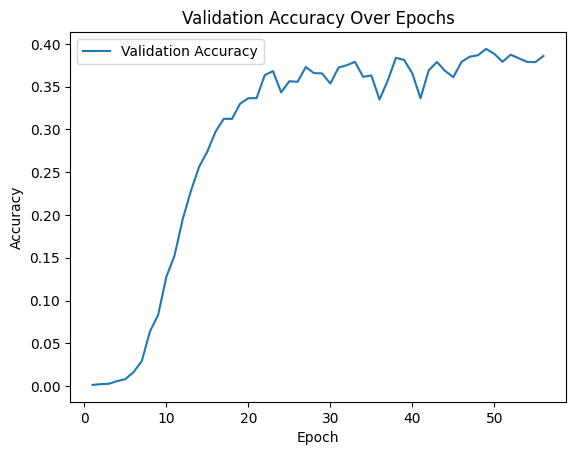

In [19]:
# Path to checkpoint
checkpoint_path = "./checkpoint.pth"

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Loading checkpoint along with epoch data
checkpoint = torch.load(checkpoint_path, map_location=device)
train_losses = checkpoint.get("train_losses", [])
val_losses = checkpoint.get("val_losses", [])
val_accuracies = checkpoint.get("val_accuracies", [])
best_val_acc = checkpoint.get("best_val_acc", 0.0)

print(f"Best Validation Accuracy: {best_val_acc:.4f}")

epochs = range(1, len(train_losses) + 1)

# Plot of the training and validation losses over epoch
plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Plot of the validation accuracy over epoch
plt.figure()
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Over Epochs")
plt.legend()
plt.show()

## Visualizing Random Images
This is used to visualize a single random image in the test set and have our model predict its class

Top-5 Prediction: ['chrysler 300 2007', 'chrysler 300 2008', 'bmw 328i 2007', 'cadillac cts 2004', 'chevrolet silverado 2010']
Top-5 Confidence: [0.9992132186889648, 0.0006282429094426334, 9.882201993605122e-05, 3.8751328247599304e-05, 8.179387805284932e-06]
Actual: chrysler 300 2007


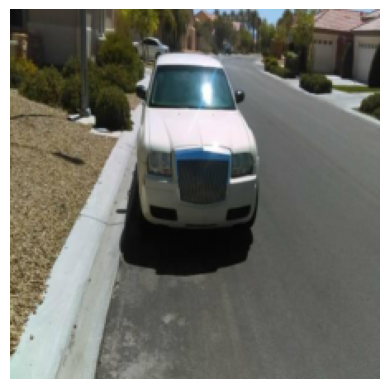

In [76]:
def predict_random_image(dataset, model, transform, class_to_idx, device):
    model.eval()

    idx = random.randint(0, len(dataset) - 1)
    image, label = dataset[idx]

    # Showing the image and undoing the pixel normalization
    mean = torch.tensor([0.4369, 0.4330, 0.4285]).view(3, 1, 1)
    std  = torch.tensor([0.2681, 0.2649, 0.2673]).view(3, 1, 1)
    image_vis = (image.cpu() * std + mean).clamp(0, 1)
    plt.imshow(image_vis.permute(1, 2, 0))
    plt.axis("off")

    # Still need Batch when passing input image into our model
    image = image.unsqueeze(0).to(device)

    # Retrieving the top 5 predictions our model makes
    with torch.no_grad():
        outputs = model(image)
        probs = F.softmax(outputs, dim=1)
        confidence_top_5, predicted_top_5 = torch.topk(probs, 5)
        confidence_top_5 = confidence_top_5.tolist()[0]
        predicted_top_5 = predicted_top_5.tolist()[0]

    idx_to_class = {v: k for k, v in class_to_idx.items()}

    # Printing out our results along with the actual label
    print(f"Top-5 Prediction: {[idx_to_class[p] for p in  predicted_top_5]}")
    print(f"Top-5 Confidence: {[c for c in  confidence_top_5]}")
    print(f"Actual: {idx_to_class[label]}")

predict_random_image(
    dataset_test,
    net,
    test_transform,
    global_class_to_idx,
    device
)

## Input Custom Images
Wanted to test some real images, and observe what our model would output.

Prediction: am general hummer 2000
Confidence: 0.9326


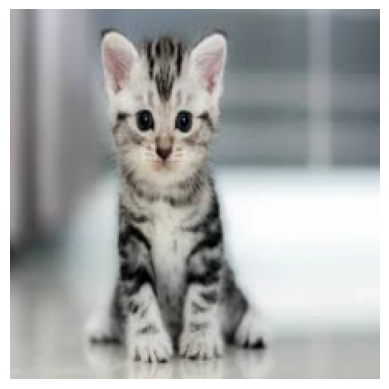

In [80]:
mean = [0.4369, 0.4330, 0.4285]
std = [0.2681, 0.2649, 0.2673]

# Input image
img = Image.open("cat.jpg").convert("RGB")
img.show()

# Need to process and transform image to input into our model
preprocess = tt.Compose([
    tt.Resize((224,224)),
    tt.ToTensor(),
    tt.Normalize(mean, std)
])
img_tensor = preprocess(img).unsqueeze(0).to(device)

# Visualizing the image
mean = torch.tensor([0.4369, 0.4330, 0.4285]).view(3, 1, 1)
std  = torch.tensor([0.2681, 0.2649, 0.2673]).view(3, 1, 1)
image_vis = (img_tensor.squeeze(0).cpu() * std + mean).clamp(0, 1)
plt.imshow(image_vis.permute(1, 2, 0))
plt.axis("off")

# Predicting a car make, model and year based on that image
with torch.no_grad():
    outputs = net(img_tensor)
    probs = F.softmax(outputs, dim=1)
    confidence, predicted = torch.max(probs, 1)

idx_to_class = {v: k for k, v in global_class_to_idx.items()}

print(f"Prediction: {idx_to_class[predicted.item()]}")
print(f"Confidence: {confidence.item():.4f}")